# Shared Eval Harness

Thin display layer only — all logging/metrics logic lives in `src/eval/logger.py` and `src/eval/metrics.py`. This notebook reads `eval_logs/*.jsonl`; it never re-trains a model itself.

**Deliberately does not import `src.models.train_baseline` or `src.models.train_slm` directly.** `xgboost` (Homebrew `libomp`) and `torch` (bundled OpenMP) loaded into one process segfault (confirmed via macOS crash reports — see `notebooks/03_slm_baseline.ipynb`). Both models' training scripts run in separate subprocesses; this notebook only reads their JSONL output.

**Two caveats carried through everything below:**
1. The text model (`text_distilbert_lora`) is trained on **synthetic** notes with an artificially injected label correlation (see `notebooks/03_slm_baseline.ipynb`) — its numbers are a pipeline sanity check, not a real finding.
2. The cohort is 129 admissions / 11 positives (8.5%) total, split further by 5-fold CV and by subgroup below. Every subgroup/calibration/drift number has single- or low-double-digit n and is **illustrative that the harness works**, not statistically defensible.

**Drift, as computed here, means run-over-run on this static dataset** (CV-fold-reshuffle / training-seed variation) — not real clinical/temporal drift. MIMIC-III's per-patient date de-identification shift (confirmed by inspecting `ADMISSIONS.csv` directly — different patients land in unrelated years) rules out admission date as a shared time axis.

In [1]:
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path("..").resolve()))

from src.eval.logger import load_all_logs
from src.eval.metrics import calibration_summary, drift_analysis, subgroup_breakdown

## Refresh logs (optional)

Flip to `True` to (re-)run both training scripts as subprocesses before loading logs — e.g. to produce a fresh run for the drift section below. Each runs in its own process (required — see the crash-avoidance note above). Off by default since SLM retraining takes a while; otherwise just run both CLIs from a terminal first: `uv run python -m src.models.train_baseline` and `uv run python -m src.models.train_slm`.

In [2]:
RUN_TRAINING_TO_REFRESH_LOGS = False

if RUN_TRAINING_TO_REFRESH_LOGS:
    for module in ["src.models.train_baseline", "src.models.train_slm"]:
        subprocess.run([sys.executable, "-m", module], cwd=Path("..").resolve(), check=True)

## Load all prediction logs

In [3]:
logs = load_all_logs(Path("..") / "eval_logs")

if logs.empty:
    print("No logs yet -- run both training scripts first (see cell above).")
else:
    print(f"{len(logs)} logged predictions across {logs['run_id'].nunique()} run(s)")
    print(logs.groupby("model")["run_id"].nunique().rename("n_runs"))

645 logged predictions across 5 run(s)
model
structured_xgboost      3
text_distilbert_lora    2
Name: n_runs, dtype: int64


## Aggregate metrics per model (sanity check)

Recomputed from the logged predictions -- should match each training script's own printed CV report.

In [4]:
from sklearn.metrics import average_precision_score, roc_auc_score

agg_rows = []
for (model, run_id), g in logs.groupby(["model", "run_id"]):
    fold_aucs = g.groupby("fold").apply(
        lambda f: pd.Series(
            {
                "roc_auc": roc_auc_score(f["ground_truth"], f["confidence"]),
                "pr_auc": average_precision_score(f["ground_truth"], f["confidence"]),
            }
        ),
        include_groups=False,
    )
    agg_rows.append(
        {
            "model": model,
            "run_id": run_id,
            "roc_auc_mean": fold_aucs["roc_auc"].mean(),
            "roc_auc_std": fold_aucs["roc_auc"].std(),
            "pr_auc_mean": fold_aucs["pr_auc"].mean(),
            "pr_auc_std": fold_aucs["pr_auc"].std(),
        }
    )
pd.DataFrame(agg_rows)

,model,run_id,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
0,structured_xgboost,20260831T215323Z,0.561413,0.174735,0.174924,0.116282
1,structured_xgboost,20260831T215333Z,0.561413,0.174735,0.174924,0.116282
2,structured_xgboost,20260831T215606Z,0.627355,0.146781,0.254852,0.187870
3,text_distilbert_lora,20260831T215425Z,0.778080,0.119503,0.335516,0.108466
4,text_distilbert_lora,20260831T215659Z,0.846014,0.096893,0.404988,0.220073


## Subgroup breakdown

**Tiny-n warning**: each row below is a slice of an already-small cohort. Read as "does the harness compute this," not "is this a reliable subgroup finding."

In [5]:
subgroups = subgroup_breakdown(logs, data_dir=Path("..") / "data" / "raw")
subgroups

,model,axis,value,n,accuracy,roc_auc,pr_auc
0,structured_xgboost,gender,female,59,0.915254,0.377193,0.039927
1,structured_xgboost,gender,male,70,0.785714,0.644809,0.276386
2,text_distilbert_lora,gender,female,59,0.966102,0.561404,0.519231
3,text_distilbert_lora,gender,male,70,0.871429,0.573770,0.221158
4,structured_xgboost,age_65_plus,65_plus,92,0.836957,0.561345,0.100302
5,structured_xgboost,age_65_plus,under_65,37,0.864865,0.780303,0.424359
6,text_distilbert_lora,age_65_plus,65_plus,92,0.923913,0.579832,0.285839
7,text_distilbert_lora,age_65_plus,under_65,37,0.891892,0.590909,0.355373
8,structured_xgboost,admission_type_emergency,emergency,119,0.831933,0.604587,0.110514
9,structured_xgboost,admission_type_emergency,non_emergency,10,1.000000,1.000000,1.000000


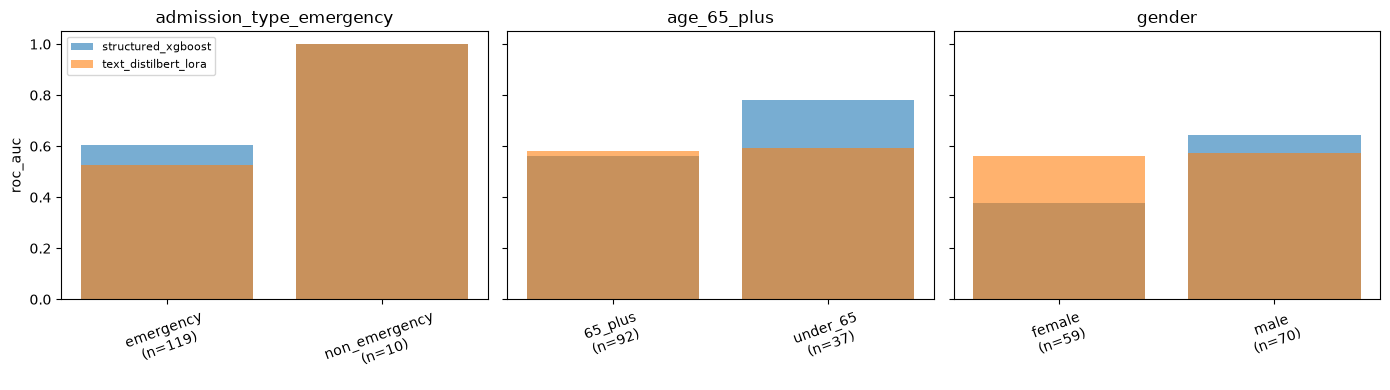

In [6]:
fig, axes = plt.subplots(1, len(subgroups["axis"].unique()), figsize=(14, 4), sharey=True)
for ax, (axis_name, g) in zip(axes, subgroups.groupby("axis")):
    for model, mg in g.groupby("model"):
        ax.bar(
            [f"{v}\n(n={n})" for v, n in zip(mg["value"], mg["n"])],
            mg["roc_auc"],
            alpha=0.6,
            label=model,
        )
    ax.set_title(axis_name)
    ax.tick_params(axis="x", rotation=20)
axes[0].set_ylabel("roc_auc")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## Calibration

Reliability diagram (predicted probability vs. observed frequency, per 5-bin) and Brier score for each model's most recent run.

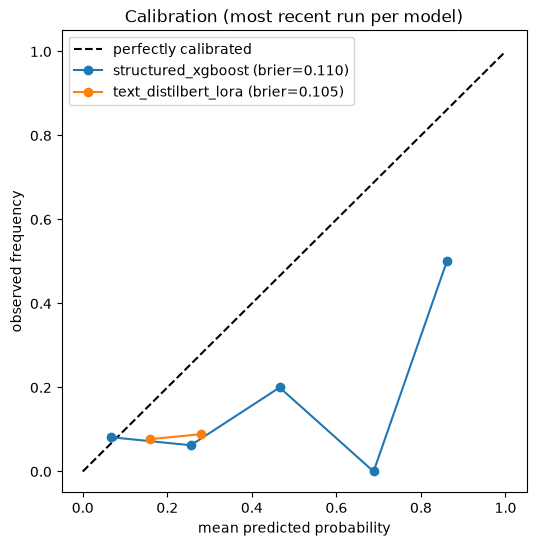

In [7]:
plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], "k--", label="perfectly calibrated")
for model in logs["model"].unique():
    cal = calibration_summary(logs, model)
    plt.plot(cal["prob_pred"], cal["prob_true"], marker="o", label=f"{model} (brier={cal['brier_score']:.3f})")
plt.xlabel("mean predicted probability")
plt.ylabel("observed frequency")
plt.title("Calibration (most recent run per model)")
plt.legend()
plt.show()

## Drift across runs

Compares each model's latest logged run against its immediately preceding run. Shows "insufficient history" cleanly when fewer than 2 runs exist for a model — expected on a fresh checkout, not an error.

In [8]:
for model in logs["model"].unique():
    result = drift_analysis(logs, model)
    print(f"--- {model} ---")
    if result["status"] == "insufficient_history":
        print(result["message"])
    else:
        print(f"comparing run {result['previous_run_id']} -> {result['latest_run_id']}")
        print(f"mean confidence: {result['mean_confidence_previous']:.3f} -> {result['mean_confidence_latest']:.3f} (shift={result['mean_confidence_shift']:+.3f})")
        print(f"roc_auc: {result['roc_auc_previous']:.3f} -> {result['roc_auc_latest']:.3f}")
        print(f"pr_auc:  {result['pr_auc_previous']:.3f} -> {result['pr_auc_latest']:.3f}")
        print(f"KS statistic={result['ks_statistic']:.3f}, p-value={result['ks_pvalue']:.3f}")
    print()

--- structured_xgboost ---
comparing run 20260831T215333Z -> 20260831T215606Z
mean confidence: 0.142 -> 0.156 (shift=+0.015)
roc_auc: 0.578 -> 0.650
pr_auc:  0.120 -> 0.211
KS statistic=0.078, p-value=0.835

--- text_distilbert_lora ---
comparing run 20260831T215425Z -> 20260831T215659Z
mean confidence: 0.217 -> 0.244 (shift=+0.027)
roc_auc: 0.602 -> 0.565
pr_auc:  0.168 -> 0.242
KS statistic=0.217, p-value=0.004



### Reading the drift section

Any drift shown above comes from CV-fold reshuffling and (for the text model) fine-tuning-init stochasticity across runs on the **same static 129-row dataset** — no new data has arrived. It demonstrates the harness's drift *machinery* (logging, run-over-run comparison, KS-test) working correctly, not a real distributional shift in incoming data. Real drift monitoring would compare production traffic over calendar time, which this project doesn't have.